In [1]:
import pandas as pd

df = pd.read_csv(r'D:\Kashish\cpi_model\data\inflation_cleaned.csv', parse_dates=['Date'], index_col='Date')
df.head()

,Inflation
Date,
2012-01-01,6.26
2012-02-01,8.03
2012-03-01,9.05
2012-04-01,9.76
2012-05-01,9.80


In [3]:
repo = pd.read_excel(
    r'D:\Kashish\cpi_model\data\repo_rate.xlsx',
    skiprows=3   # skip junk rows
)

c:\Users\Kashish\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [4]:
print(repo.head())
print(repo.columns)

   Unnamed: 0           Unnamed: 1    4 Interest Rates (%)
0         NaN                 Date  4.1   Policy Repo Rate
1         NaN                  NaN                     NaN
2         NaN                 2026                     NaN
3         NaN  2026-01-31 00:00:00                    5.25
4         NaN                 2025                     NaN
Index(['Unnamed: 0', 'Unnamed: 1', '4 Interest Rates (%)'], dtype='object')


In [5]:
repo = repo[['Unnamed: 1', '4 Interest Rates (%)']]
repo.columns = ['Date', 'Repo_Rate']

In [6]:
repo = repo[pd.to_datetime(repo['Date'], errors='coerce').notnull()]

C:\Users\Kashish\AppData\Local\Temp\ipykernel_29320\1174960085.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  repo = repo[pd.to_datetime(repo['Date'], errors='coerce').notnull()]


In [7]:
pd.to_datetime(repo['Date'], errors='coerce')

2     1970-01-01 00:00:00.000002026
3     2026-01-31 00:00:00.000000000
4     1970-01-01 00:00:00.000002025
5     2025-12-31 00:00:00.000000000
6     2025-11-30 00:00:00.000000000
                   ...             
196   2011-03-31 00:00:00.000000000
197   2011-02-28 00:00:00.000000000
198   2011-01-31 00:00:00.000000000
199   1970-01-01 00:00:00.000002010
200   2010-12-31 00:00:00.000000000
Name: Date, Length: 199, dtype: datetime64[ns]

In [8]:
repo = repo[repo['Unnamed: 1'].astype(str).str.contains('-')]

KeyError: 'Unnamed: 1'

In [9]:
print(repo.columns.tolist())

['Date', 'Repo_Rate']


In [10]:
repo['Date'] = pd.to_datetime(repo['Date'])

In [11]:
repo = repo.sort_values('Date')
repo = repo.set_index('Date')

In [12]:
repo = repo.resample('MS').ffill()

In [13]:
repo.head()
repo.tail()

,Repo_Rate
Date,
2025-09-01,5.5
2025-10-01,5.5
2025-11-01,5.5
2025-12-01,5.5
2026-01-01,5.25


In [14]:
merged = df.join(repo, how='inner')
merged.head()

,Inflation,Repo_Rate
Date,,
2012-01-01,6.26,8.5
2012-02-01,8.03,8.5
2012-03-01,9.05,8.5
2012-04-01,9.76,8.5
2012-05-01,9.80,8


In [15]:
merged.isnull().sum()

Inflation    0
Repo_Rate    0
dtype: int64

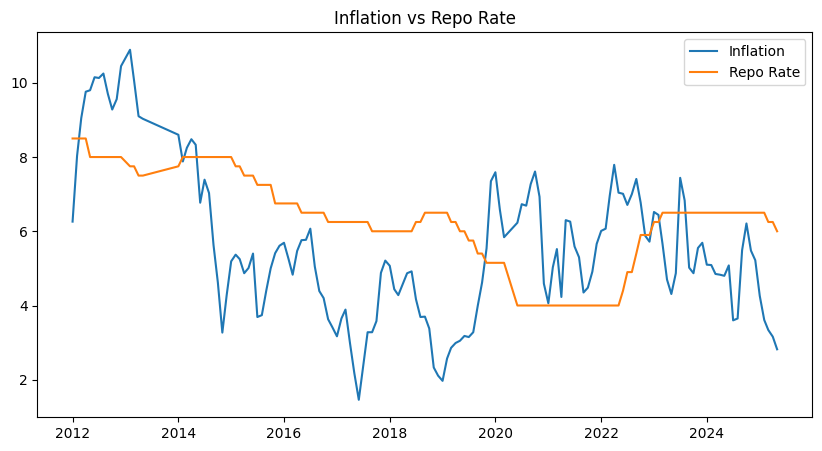

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(merged['Inflation'], label='Inflation')
plt.plot(merged['Repo_Rate'], label='Repo Rate')
plt.legend()
plt.title("Inflation vs Repo Rate")
plt.show()

In [17]:
merged['Repo_Lag_1'] = merged['Repo_Rate'].shift(1)
merged['Repo_Lag_2'] = merged['Repo_Rate'].shift(2)
merged['Repo_Lag_3'] = merged['Repo_Rate'].shift(3)

In [18]:
merged = merged.dropna()

In [19]:
merged.head()

,Inflation,Repo_Rate,Repo_Lag_1,Repo_Lag_2,Repo_Lag_3
Date,,,,,
2012-04-01,9.76,8.5,8.5,8.5,8.5
2012-05-01,9.80,8,8.5,8.5,8.5
2012-06-01,10.15,8,8,8.5,8.5
2012-07-01,10.13,8,8,8,8.5
2012-08-01,10.25,8,8,8,8


In [25]:
from sklearn.linear_model import LinearRegression

X = merged[['Repo_Lag_1', 'Repo_Lag_2', 'Repo_Lag_3']]
y = merged['Inflation']

model = LinearRegression()
model.fit(X, y)

merged['Predicted'] = model.predict(X)

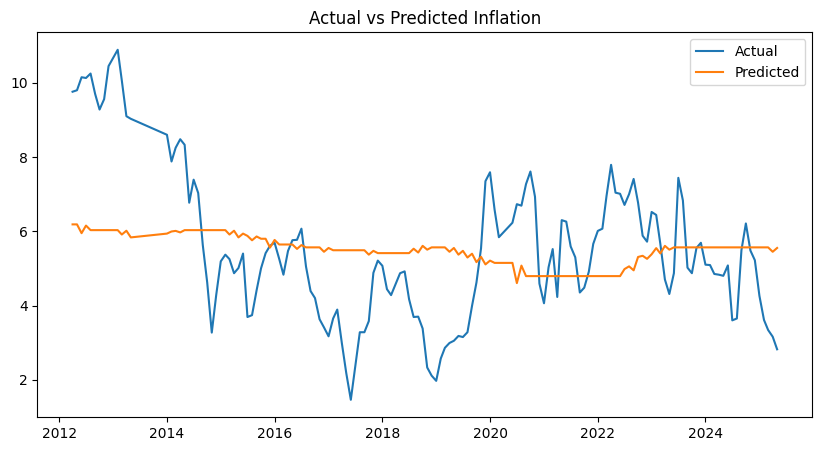

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(merged['Inflation'], label='Actual')
plt.plot(merged['Predicted'], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Inflation")
plt.show()

In [27]:
for i in range(1, 7):
    merged[f'Repo_Lag_{i}'] = merged['Repo_Rate'].shift(i)

merged = merged.dropna()

In [28]:
X = merged[[f'Repo_Lag_{i}' for i in range(1,7)]]
y = merged['Inflation']

model = LinearRegression()
model.fit(X, y)

merged['Predicted'] = model.predict(X)

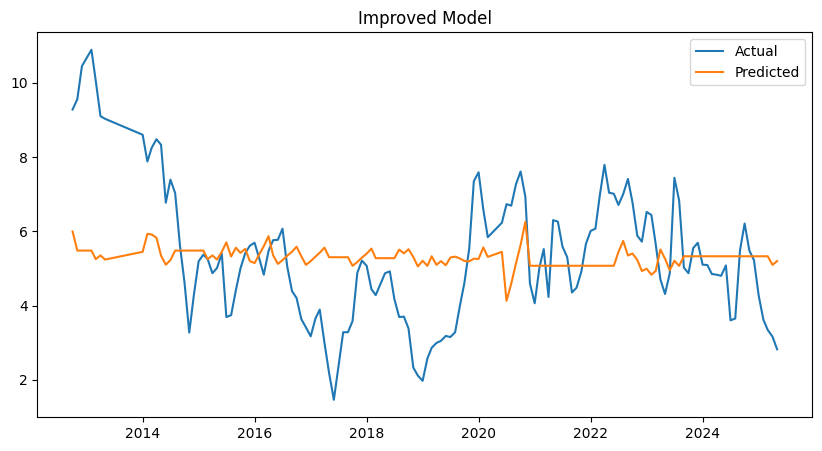

In [29]:
plt.figure(figsize=(10,5))
plt.plot(merged['Inflation'], label='Actual')
plt.plot(merged['Predicted'], label='Predicted')
plt.legend()
plt.title("Improved Model")
plt.show()

In [31]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y, merged['Predicted'])
r2 = r2_score(y, merged['Predicted'])

print("MAE:", mae)
print("R2 Score:", r2)



# “The low R² score indicates that monetary policy, as captured by repo rate, has limited standalone explanatory power over inflation, highlighting the importance of supply-side and external factors.”

MAE: 1.4068372164643852
R2 Score: 0.018687476723574403


In [32]:
merged['Inflation_Lag_1'] = merged['Inflation'].shift(1)
merged = merged.dropna()

X = merged[['Repo_Lag_1','Repo_Lag_2','Repo_Lag_3','Inflation_Lag_1']]
y = merged['Inflation']

model = LinearRegression()
model.fit(X, y)

merged['Predicted'] = model.predict(X)

In [34]:
from sklearn.metrics import r2_score
print("R2:", r2_score(y, merged['Predicted']))


# The high R² after including lagged inflation indicates strong persistence in inflation dynamics, where past inflation is a dominant predictor of current inflation.”

R2: 0.8387138329519771


In [35]:
merged.corr()

,Inflation,Repo_Rate,Repo_Lag_1,Repo_Lag_2,Repo_Lag_3,Predicted,Repo_Lag_4,Repo_Lag_5,Repo_Lag_6,Inflation_Lag_1
Inflation,1.000000,0.056931,0.038572,0.030656,0.027133,0.915813,0.027892,0.032110,0.036664,0.913485
Repo_Rate,0.056931,1.000000,0.990677,0.979376,0.964506,0.063237,0.947443,0.927713,0.906465,0.101137
Repo_Lag_1,0.038572,0.990677,1.000000,0.990961,0.979820,0.042117,0.965542,0.948699,0.929224,0.078918
Repo_Lag_2,0.030656,0.979376,0.990961,1.000000,0.991103,0.033474,0.980240,0.966156,0.949540,0.062439
Repo_Lag_3,0.027133,0.964506,0.979820,0.991103,1.000000,0.029627,0.991366,0.980646,0.966749,0.054230
Predicted,0.915813,0.063237,0.042117,0.033474,0.029627,1.000000,0.029931,0.032528,0.038570,0.997458
Repo_Lag_4,0.027892,0.947443,0.965542,0.980240,0.991366,0.029931,1.000000,0.991491,0.980922,0.052323
Repo_Lag_5,0.032110,0.927713,0.948699,0.966156,0.980646,0.032528,0.991491,1.000000,0.991611,0.052671
Repo_Lag_6,0.036664,0.906465,0.929224,0.949540,0.966749,0.038570,0.980922,0.991611,1.000000,0.056427
Inflation_Lag_1,0.913485,0.101137,0.078918,0.062439,0.054230,0.997458,0.052323,0.052671,0.056427,1.000000


In [36]:
for i in range(1,7):
    print(i, merged['Inflation'].corr(merged[f'Repo_Lag_{i}']))

1 0.038571657529957296
2 0.03065634866509194
3 0.027132914231368686
4 0.027891516759802084
5 0.03210989495831825
6 0.03666444782458854


In [40]:
from sklearn.ensemble import RandomForestRegressor

In [41]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

RandomForestRegressor(random_state=42)

In [42]:
merged['RF_Predicted'] = rf.predict(X)

In [43]:
from sklearn.metrics import r2_score

print("Linear R2:", r2_score(y, merged['Predicted']))
print("RF R2:", r2_score(y, merged['RF_Predicted']))

Linear R2: 0.8387138329519771
RF R2: 0.9644430685154627


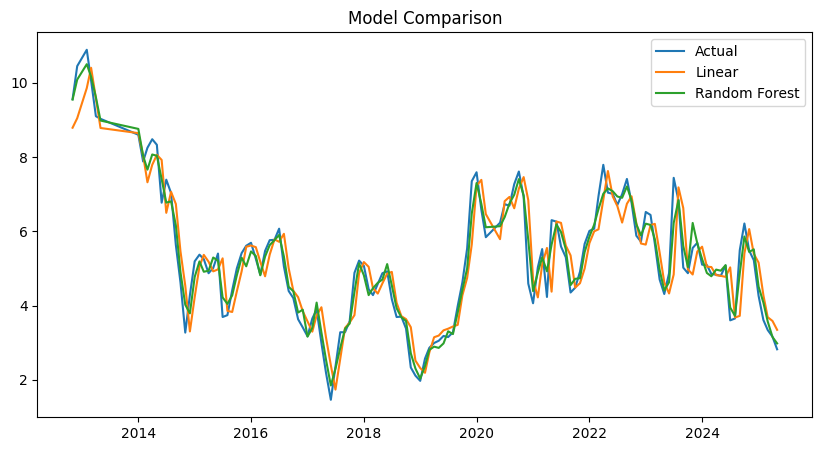

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(merged['Inflation'], label='Actual')
plt.plot(merged['Predicted'], label='Linear')
plt.plot(merged['RF_Predicted'], label='Random Forest')
plt.legend()
plt.title("Model Comparison")
plt.show()

<Axes: title={'center': 'Feature Importance'}>

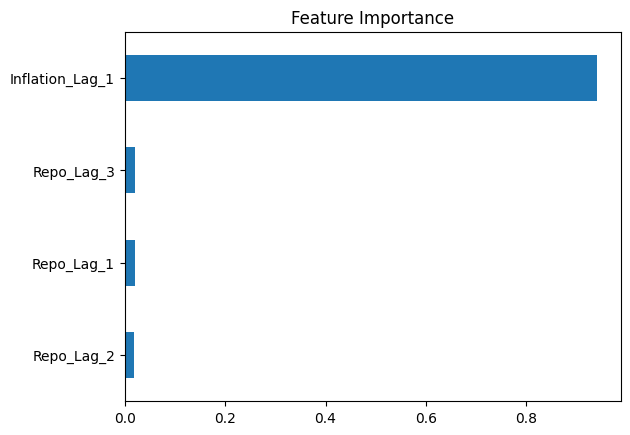

In [45]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', title='Feature Importance')

In [46]:
merged.to_csv('D:CPI_MODEL//data/processed/merged_data.csv')

OSError: Cannot save file into a non-existent directory: 'D:CPI_MODEL\data\processed'